# REENTRENAMIENTO LOCAL DE YOLO11 CON DATASET DE VEHÍCULOS

En este tutorial se usa un set de imágenes propio para afinar/reentrenar el modelo YOLO11 de Ultralytics en una máquina local.

Contenido:

1. ¿Qué es YOLO11?
2. Objetivo del tutorial
3. Preparación local del dataset
4. Afinación de YOLO11 con el dataset
5. Generación de predicciones con el modelo afinado


## Configuración para ejecución local


Suposición práctica: coloca en una misma carpeta estos tres archivos:

- este notebook `.ipynb`
- `dataset_vehiculos.zip`
- `yolo11n.pt` 



## 2. Objetivo 

En este veremos cómo afinar el modelo YOLO11 de detección de objetos usando un dataset propio.

## 3. Preparación del dataset

Según la documentación de Ultralytics, el set de imágenes debe estar estructurado de esta manera:

![](https://github.com/ultralytics/docs/releases/download/0/two-persons-tie-2.avif)

Además, los modelos disponibles son los siguientes:

![](https://drive.google.com/uc?export=view&id=1PYaeIKj57C4_nys6XPAJrZ2tfdwiYEZQ)


En todos los casos la dimensión más grande a usar en las imágenes es de 640 pixeles, así que tendremos que ajustar las imágenes de nuestro set de datos a este tamaño.

Además, usaremos el modelo más pequeño (YOLO11n) que contiene 2.6 millones de parámetros.

Estos son los pasos para tener disponible el set de datos desde Google Colab:

1. Primero debemos crear la carpeta "datasets" en el directorio "content" de Google Colab
2. Ahora descargamos el set de datos desde [este enlace](https://drive.google.com/file/d/15p5c3dGq3sm2bNUCevnHEOnwyC3MpE6L/view?usp=sharing).
3. Una vez descargado el archivo "dataset-vehiculos.zip" lo llevamos a la carpeta "datasets" de Google Colab
4. Ahora descomprimimos el archivo .zip:

In [1]:
from pathlib import Path
import os
import sys
import shutil
import zipfile
import yaml

# ============================================================
# CONFIGURACIÓN LOCAL
# ============================================================
# Opción recomendada:
#   Guarda este notebook, dataset_vehiculos.zip y yolo11n.pt
#   en la misma carpeta, y deja BASE_DIR = Path.cwd().
#
# Si tus archivos están en otra ruta, reemplaza Path.cwd() por tu ruta local.
# Ejemplo Windows:
#   BASE_DIR = Path(r"D:\CICLO 2026-1 UNI\YOLO_VEHICULOS")
# Ejemplo Linux:
#   BASE_DIR = Path("/home/cesar/YOLO_VEHICULOS")
BASE_DIR = Path.cwd()

DATASETS_DIR = BASE_DIR / "datasets"
DATASET_DIR = DATASETS_DIR / "dataset_vehiculos"
YAML_PATH = DATASET_DIR / "data.yaml"

RUNS_DIR = BASE_DIR / "runs"
EXPERIMENT_NAME = "vehiculos_yolo11n"

# Parámetros principales de entrenamiento
EPOCHS = 10
IMG_SIZE = 640
BATCH_SIZE = 8

# ============================================================
# BÚSQUEDA ROBUSTA DE ARCHIVOS LOCALES
# ============================================================
def buscar_archivo(base_dir: Path, nombres_exactos, patron_glob: str) -> Path:
    """
    Busca primero por nombres exactos y luego por patrón glob dentro de BASE_DIR.
    No usa rutas de Google Colab.
    """
    for nombre in nombres_exactos:
        candidato = base_dir / nombre
        if candidato.exists():
            return candidato

    candidatos = sorted(base_dir.glob(patron_glob))
    if candidatos:
        return candidatos[0]

    raise FileNotFoundError(
        f"No se encontró el archivo. Revisé estos nombres: {nombres_exactos} "
        f"y el patrón '{patron_glob}' dentro de: {base_dir}"
    )

DATASET_ZIP = buscar_archivo(
    BASE_DIR,
    nombres_exactos=["dataset_vehiculos.zip"],
    patron_glob="dataset_vehiculos*.zip"
)

MODEL_PATH = buscar_archivo(
    BASE_DIR,
    nombres_exactos=["yolo11n.pt", "yolo11n(3).pt"],
    patron_glob="yolo11n*.pt"
)

print("BASE_DIR       :", BASE_DIR)
print("DATASET_ZIP    :", DATASET_ZIP)
print("MODEL_PATH     :", MODEL_PATH)
print("DATASET_DIR    :", DATASET_DIR)
print("YAML_PATH      :", YAML_PATH)
print("RUNS_DIR       :", RUNS_DIR)



# ============================================================
# EXTRACCIÓN DEL DATASET LOCAL
# ============================================================
DATASETS_DIR.mkdir(parents=True, exist_ok=True)

if DATASET_DIR.exists():
    print(f"El dataset ya existe en: {DATASET_DIR}")
    print("No se vuelve a extraer para no sobrescribir archivos existentes.")
else:
    print(f"Extrayendo {DATASET_ZIP.name} en {DATASETS_DIR} ...")
    with zipfile.ZipFile(DATASET_ZIP, "r") as zip_ref:
        zip_ref.extractall(DATASETS_DIR)
    print("Extracción completada.")

# Verificación de carpetas esperadas por YOLO
rutas_requeridas = [
    DATASET_DIR / "images" / "train",
    DATASET_DIR / "images" / "val",
    DATASET_DIR / "images" / "test",
    DATASET_DIR / "labels" / "train",
    DATASET_DIR / "labels" / "val",
    DATASET_DIR / "labels" / "test",
]

for ruta in rutas_requeridas:
    if not ruta.exists():
        raise FileNotFoundError(f"Falta la carpeta requerida: {ruta}")

print("Estructura del dataset verificada correctamente.")


BASE_DIR       : d:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\vehiculos
DATASET_ZIP    : d:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\vehiculos\dataset_vehiculos.zip
MODEL_PATH     : d:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\vehiculos\yolo11n.pt
DATASET_DIR    : d:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\vehiculos\datasets\dataset_vehiculos
YAML_PATH      : d:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\vehiculos\datasets\dataset_vehiculos\data.yaml
RUNS_DIR       : d:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\vehiculos\runs
Extrayendo dataset_vehiculos.zip en d:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\vehiculos\datasets ...
Extracción completada.
Estructura del dataset verificada correctamente.


Y finalmente podemos eliminar el archivo .zip.

Verifiquemos que la estructura del set de datos es la especificada en la documentación de Ultralytics.

En total tendremos:

- 399 imágenes de entrenamiento
- 50 imágenes de validación
- 50 imágenes de prueba

Además, por cada imagen tendremos una etiqueta correspondiente. Esta etiqueta es un archivo que contiene el mismo nombre de la imagen y ubicado en la carpeta "labels".

Acá un ejemplo de uno de estos archivos:



```
0 0.217969 0.441667 0.091146 0.129630
0 0.332552 0.242593 0.043229 0.100000
0 0.291406 0.125463 0.031771 0.060185
0 0.238802 0.138426 0.031771 0.060185
0 0.297396 0.049074 0.023958 0.038889
0 0.320052 0.019907 0.017188 0.030556
0 0.465104 0.316204 0.055208 0.125000
0 0.495052 0.482407 0.067187 0.177778
0 0.141406 0.965278 0.116146 0.069444
```

En este caso:

- Cada fila corresponde a un objeto presente en la imagen. En total tendremos 9 filas y por tanto un total de 9 objetos
- Por cada objeto tendremos esta información: `class x_center y_center width height`.

Como en este caso queremos afinar el modelo para que detecte un solo tipo de objeto (0: vehículo) por tanto tendremos en todos los casos la categoría 0.

Observemos que las coordenadas del "bounding box" de cada objeto están normalizadas al tamaño de la imagen:

![](https://github.com/ultralytics/docs/releases/download/0/two-persons-tie.avif)

Ahora debemos crear el archivo .YAML que es como el índice del dataset y que debe seguir esta estructura:

```
path: ../datasets/coco8 # dataset root dir
train: images/train # train images (relative to 'path') 4 images
val: images/val # val images (relative to 'path') 4 images
test: # test images (optional)

# Classes (80 COCO classes)
names:
    0: person
    1: bicycle
    2: car
    # ...
    77: teddy bear
    78: hair drier
    79: toothbrush
```

Usemos el módulo "yaml" para crear este archivo:


In [3]:
# ============================================================
# CREACIÓN DEL ARCHIVO data.yaml PARA YOLO
# ============================================================
data = {
    "path": str(DATASET_DIR.resolve()).replace("\\", "/"),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {
        0: "car"
    }
}

with open(YAML_PATH, "w", encoding="utf-8") as file:
    yaml.dump(
        data,
        file,
        default_flow_style=False,
        sort_keys=False,
        allow_unicode=True
    )

print(f"Archivo YAML creado en: {YAML_PATH}")
print("\nContenido de data.yaml:\n")
print(YAML_PATH.read_text(encoding="utf-8"))

# ============================================================
# VALIDACIÓN DE IMÁGENES Y ETIQUETAS
# ============================================================
extensiones_imagen = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for split in ["train", "val", "test"]:
    images_dir = DATASET_DIR / "images" / split
    labels_dir = DATASET_DIR / "labels" / split

    imagenes = [
        p for p in images_dir.iterdir()
        if p.suffix.lower() in extensiones_imagen
    ]
    labels = list(labels_dir.glob("*.txt"))

    nombres_imagen = {p.stem for p in imagenes}
    nombres_label = {p.stem for p in labels}

    faltan_labels = nombres_imagen - nombres_label
    labels_sin_imagen = nombres_label - nombres_imagen

    print(f"{split:5s} -> imágenes: {len(imagenes):4d} | labels: {len(labels):4d}")

    if faltan_labels:
        raise ValueError(f"Hay imágenes sin label en {split}: {sorted(list(faltan_labels))[:10]}")

    if labels_sin_imagen:
        raise ValueError(f"Hay labels sin imagen en {split}: {sorted(list(labels_sin_imagen))[:10]}")

print("\nDataset listo para entrenamiento YOLO.")


Archivo YAML creado en: d:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\vehiculos\datasets\dataset_vehiculos\data.yaml

Contenido de data.yaml:

path: D:/CICLO 2026-1 UNI/Project_IA/[2] CODIGO/REENTRENAMIENTO_YOLO/vehiculos/datasets/dataset_vehiculos
train: images/train
val: images/val
test: images/test
names:
  0: car

train -> imágenes:  399 | labels:  399
val   -> imágenes:   50 | labels:   50
test  -> imágenes:   50 | labels:   50

Dataset listo para entrenamiento YOLO.


Y listo. Ya tenemos listo el set de datos y ya podemos comenzar a hacer la afinación.

## 4. Afinación de YOLO11 (detección) con el dataset

Para poder acceder al modelo pre-entrenado debemos comenzar instalando la librería "ultralytics":

In [4]:
# ============================================================
# INSTALACIÓN / VERIFICACIÓN DE ULTRALYTICS
# ============================================================
import importlib.util
import subprocess

if importlib.util.find_spec("ultralytics") is None:
    print("Ultralytics no está instalado. Instalando...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "ultralytics"])
else:
    print("Ultralytics ya está instalado.")

from ultralytics import YOLO

print("Importación de YOLO correcta.")


Ultralytics ya está instalado.
Importación de YOLO correcta.


Y tan sólo debemos llevar a cabo estos dos pasos para afinar el modelo:

1. Importar el modelo pre-entrenado
2. Usar el método "train" para realizar la afinación

Por defecto en cada iteración de entrenamiento se almacenarán los pesos del modelo afinado en la carpeta "runs". Se recomienda realizar la afinación usando la GPU (aunque con la CPU es posible, simplemente se requerirá más tiempo):

In [6]:
from ultralytics import YOLO
import torch

# Usa GPU si está disponible. Si no, usa CPU.
DEVICE = 0 if torch.cuda.is_available() else "cpu"

print("Dispositivo de entrenamiento:", DEVICE)
print("Modelo base:", MODEL_PATH)
print("Dataset YAML:", YAML_PATH)

# 1. Cargar el modelo preentrenado local
model = YOLO(str(MODEL_PATH))

# 2. Reentrenar / afinar el modelo
results = model.train(
    data=str(YAML_PATH),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=0,          # Importante en Windows/Jupyter para evitar bloqueos con DataLoader
    project=str(RUNS_DIR),
    name=EXPERIMENT_NAME,
    exist_ok=True,
    plots=True
)

BEST_MODEL_PATH = RUNS_DIR / EXPERIMENT_NAME / "weights" / "best.pt"
LAST_MODEL_PATH = RUNS_DIR / EXPERIMENT_NAME / "weights" / "last.pt"

print("\nEntrenamiento terminado.")
print("Mejor modelo :", BEST_MODEL_PATH)
print("Último modelo:", LAST_MODEL_PATH)


Dispositivo de entrenamiento: cpu
Modelo base: d:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\vehiculos\yolo11n.pt
Dataset YAML: d:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\vehiculos\datasets\dataset_vehiculos\data.yaml
New https://pypi.org/project/ultralytics/8.4.81 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.62  Python-3.14.0 torch-2.12.0+cpu CPU (Intel Core i7-7700 3.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=d:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\vehiculos\datasets\dataset_vehiculos\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=Tru

Al realizar la afinación veremos impresas en pantalla varias métricas de las cuáles las más importantes son:

- "box_loss": mide el error en la ubicación y tamaño de los "bounding boxes" predichos en comparación con los de referencia. Se calcula como 1 - IntersectionOverUnion.
- "cls_loss": es el error en la clasificación del objeto dentro del "bounding box". Se calcula como la entropía cruzada
- "mAP": la precisión media que mide qué tan buenas detecciones genera el modelo (entre más cercano a 1 sea este valor mejor será el desempeño).

Después de unos minutos tendremos el modelo ya afinado. Este quedará almacenado en la carpeta `../runs/detect/train/weights/best.pt'`.

Podemos generar algunos gráficos del proceso de entrenamiento y validación para verificar que no haya "overfitting".

Por ejemplo grafiquemos las pérdidas para entrenamiento y validación:

Carpeta real usada para resultados: d:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\vehiculos\runs\vehiculos_yolo11n
No existe results.png, pero sí existe results.csv.
Voy a generar una gráfica manual desde results.csv.


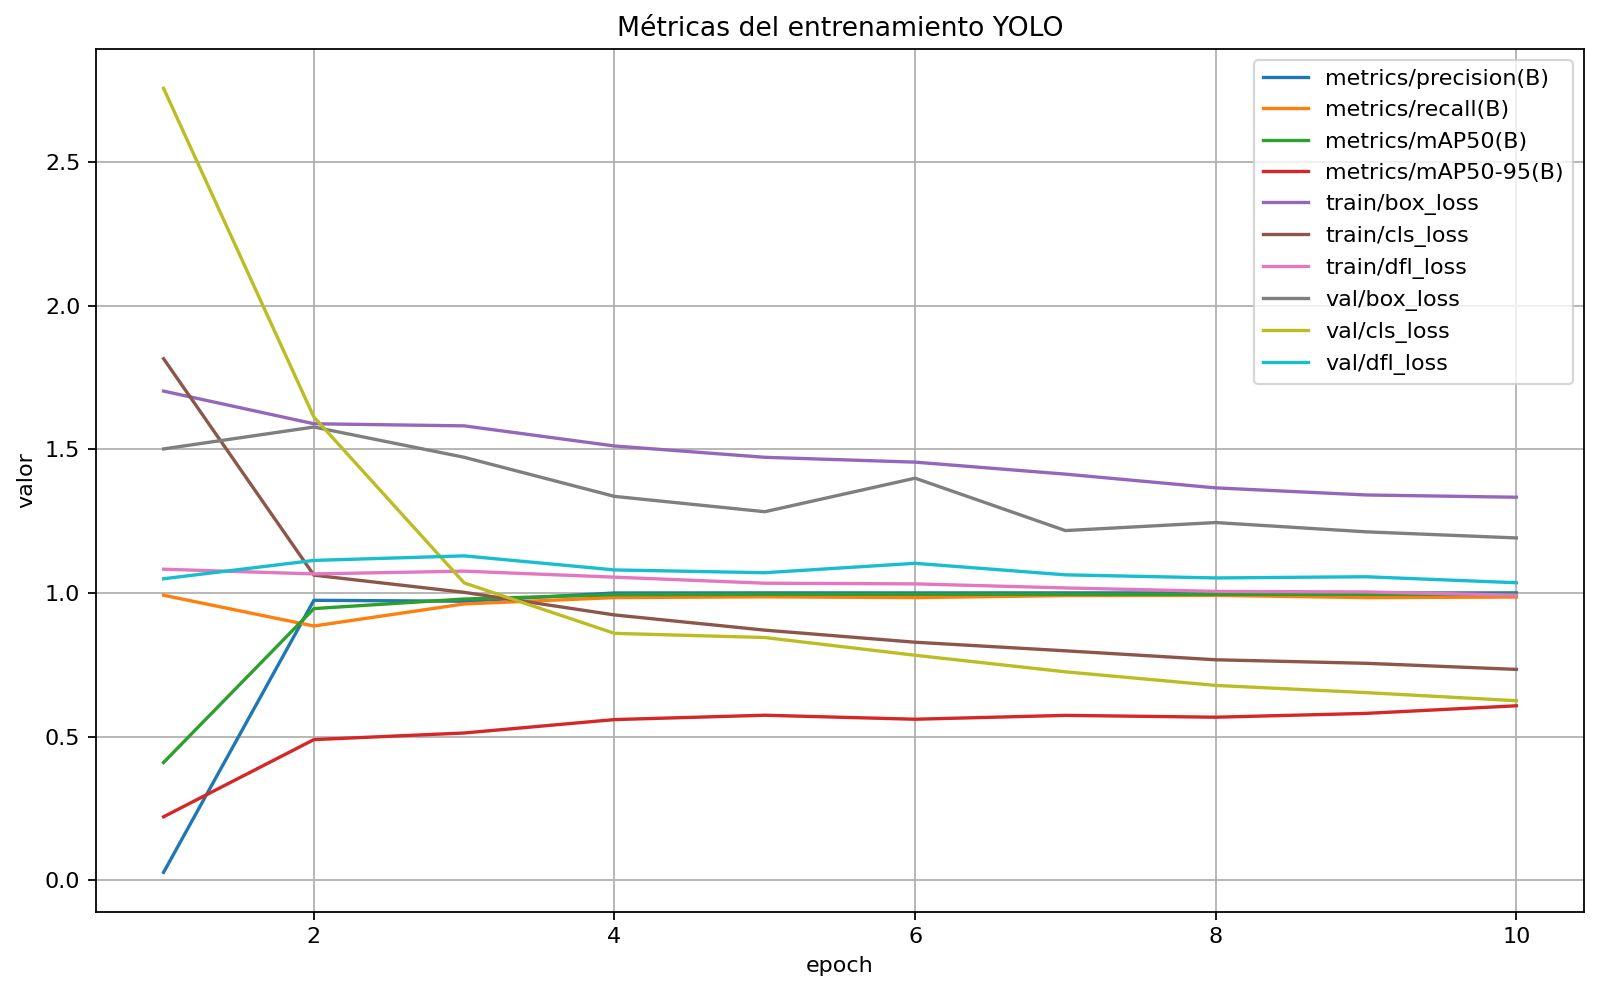

In [15]:
from IPython.display import Image as IPyImage, display
from pathlib import Path

def obtener_train_dir() -> Path:
    runs_dir = Path(RUNS_DIR)
    candidatos = []

    def registrar(carpeta: Path):
        carpeta = Path(carpeta)
        if not carpeta.exists() or not carpeta.is_dir():
            return

        results_png = carpeta / "results.png"
        results_csv = carpeta / "results.csv"
        best_pt = carpeta / "weights" / "best.pt"
        last_pt = carpeta / "weights" / "last.pt"

        archivos_validos = [p for p in [results_png, results_csv, best_pt, last_pt] if p.exists()]
        if not archivos_validos:
            return

        prioridad = 0
        if results_png.exists():
            prioridad += 100
        if results_csv.exists():
            prioridad += 50
        if best_pt.exists():
            prioridad += 20
        if last_pt.exists():
            prioridad += 10

        mtime = max(p.stat().st_mtime for p in archivos_validos)
        candidatos.append((prioridad, mtime, carpeta))

    if "TRAIN_DIR" in globals():
        registrar(Path(TRAIN_DIR))

    registrar(runs_dir / EXPERIMENT_NAME)

    if runs_dir.exists():
        for p in runs_dir.rglob("results.png"):
            registrar(p.parent)
        for p in runs_dir.rglob("results.csv"):
            registrar(p.parent)
        for p in runs_dir.rglob("best.pt"):
            registrar(p.parent.parent)
        for p in runs_dir.rglob("last.pt"):
            registrar(p.parent.parent)

    if candidatos:
        candidatos = sorted(set(candidatos), key=lambda x: (x[0], x[1]), reverse=True)
        return candidatos[0][2]

    raise FileNotFoundError(
        "No se encontró una corrida válida. Ejecuta primero la celda de entrenamiento "
        "y verifica que termine sin errores."
    )


TRAIN_DIR = obtener_train_dir()
results_png = TRAIN_DIR / "results.png"
results_csv = TRAIN_DIR / "results.csv"

print("Carpeta real usada para resultados:", TRAIN_DIR)

if results_png.exists():
    display(IPyImage(filename=str(results_png), width=850))

elif results_csv.exists():
    print("No existe results.png, pero sí existe results.csv.")
    print("Voy a generar una gráfica manual desde results.csv.")

    import pandas as pd
    import matplotlib.pyplot as plt

    df = pd.read_csv(results_csv)
    df.columns = [c.strip() for c in df.columns]

    columnas_preferidas = [
        "metrics/precision(B)",
        "metrics/recall(B)",
        "metrics/mAP50(B)",
        "metrics/mAP50-95(B)",
        "train/box_loss",
        "train/cls_loss",
        "train/dfl_loss",
        "val/box_loss",
        "val/cls_loss",
        "val/dfl_loss",
    ]

    columnas = [c for c in columnas_preferidas if c in df.columns]

    if not columnas:
        raise FileNotFoundError(
            f"Se encontró results.csv en {results_csv}, pero no contiene columnas métricas esperadas."
        )

    eje_x = df["epoch"] if "epoch" in df.columns else range(1, len(df) + 1)

    plt.figure(figsize=(12, 7))
    for c in columnas:
        plt.plot(eje_x, df[c], label=c)

    plt.xlabel("epoch")
    plt.ylabel("valor")
    plt.title("Métricas del entrenamiento YOLO")
    plt.grid(True)
    plt.legend()

    manual_png = TRAIN_DIR / "results_manual.png"
    plt.savefig(manual_png, dpi=160, bbox_inches="tight")
    plt.close()

    display(IPyImage(filename=str(manual_png), width=850))

else:
    print("Archivos encontrados en la carpeta de entrenamiento:")
    for p in sorted(TRAIN_DIR.rglob("*"))[:120]:
        print(" -", p.relative_to(TRAIN_DIR))

    raise FileNotFoundError(
        f"No se encontró results.png ni results.csv en: {TRAIN_DIR}\n"
        "Esto normalmente significa que el entrenamiento no terminó completamente."
    )

Y al observar estas gráficas vemos que convergen a valores muy cercanos tanto en entrenamiento como en validación y por tanto podemos concluir que el modelo afinado generaliza bastante bien.

Podemos ver el desempeño de la clasificación de los objetos (dentro del proceso de detección) graficando la matriz de confusión:

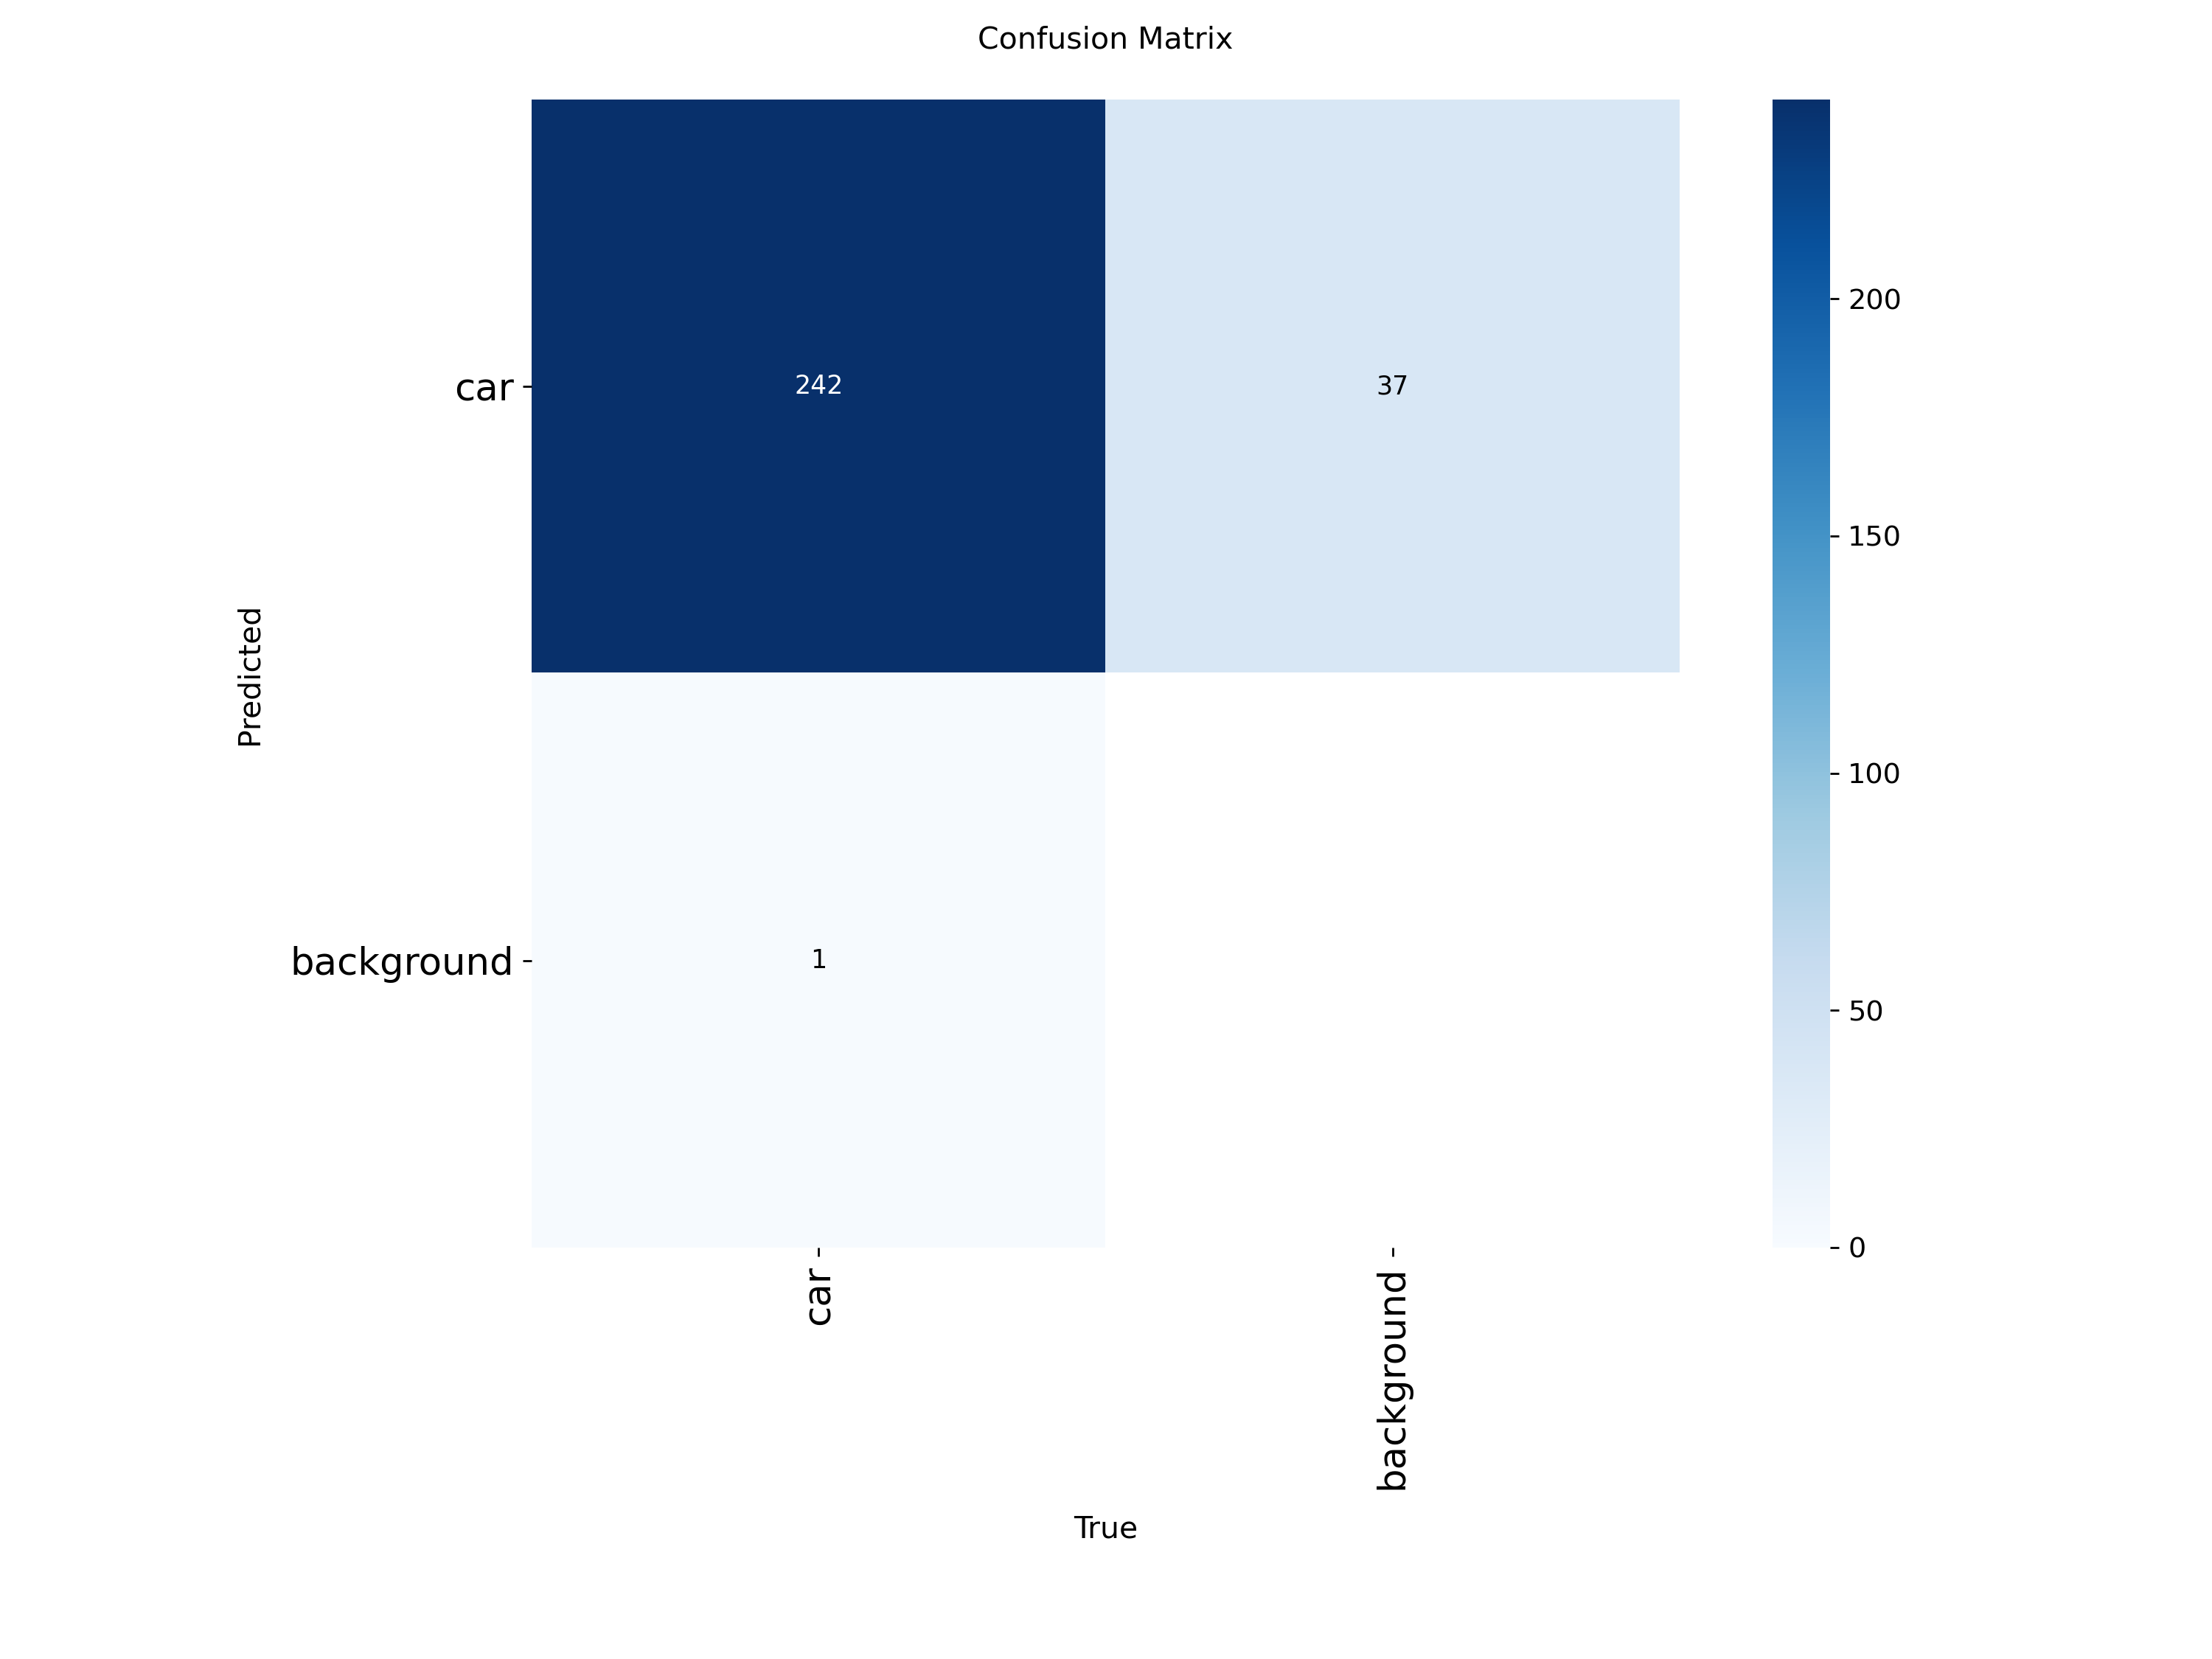

In [10]:
from IPython.display import Image as IPyImage, display

confusion_png = RUNS_DIR / EXPERIMENT_NAME / "confusion_matrix.png"

if not confusion_png.exists():
    raise FileNotFoundError(
        f"No se encontró confusion_matrix.png en: {confusion_png}. "
        "Ejecuta primero la celda de entrenamiento."
    )

display(IPyImage(filename=str(confusion_png), width=600))


Y podemos ver que por ejemplo 1 vehículo ha sido detectado incorrectamente como fondo mientras que 20 porciones del fondo han sido detectadas incorrectamente como vehículos.

Incluso podemos ver el detalle de los datos usados para generar estas gráficas en el archivo results.csv.

## 5. Generación de predicciones con el modelo afinado

Y por último, podemos usar el set de prueba (disponible en la carpeta ``DATASET_DIR / "images" / "test"``) para generar predicciones sobre nuevos datos usando el modelo afinado.

Comencemos cargando el modelo afinado:

In [11]:
from ultralytics import YOLO

BEST_MODEL_PATH = RUNS_DIR / EXPERIMENT_NAME / "weights" / "best.pt"

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró el modelo afinado: {BEST_MODEL_PATH}. "
        "Ejecuta primero la celda de entrenamiento."
    )

model = YOLO(str(BEST_MODEL_PATH))
print("Modelo afinado cargado:", BEST_MODEL_PATH)


Modelo afinado cargado: d:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\vehiculos\runs\vehiculos_yolo11n\weights\best.pt


Y ahora generemos predicciones sobre la totalidad del set de prueba (50 imágenes):

In [12]:
test_dir = DATASET_DIR / "images" / "test"

if not test_dir.exists():
    raise FileNotFoundError(f"No se encontró la carpeta de test: {test_dir}")

preds = model.predict(
    source=str(test_dir),
    imgsz=IMG_SIZE,
    save=True,
    project=str(RUNS_DIR),
    name=f"{EXPERIMENT_NAME}_predicciones",
    exist_ok=True
)

print(f"Predicciones generadas: {len(preds)}")
print("Resultados guardados en:", RUNS_DIR / f"{EXPERIMENT_NAME}_predicciones")



image 1/50 d:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\vehiculos\datasets\dataset_vehiculos\images\test\frame_0449.jpg: 384x640 5 cars, 125.2ms
image 2/50 d:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\vehiculos\datasets\dataset_vehiculos\images\test\frame_0450.jpg: 384x640 6 cars, 91.4ms
image 3/50 d:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\vehiculos\datasets\dataset_vehiculos\images\test\frame_0451.jpg: 384x640 5 cars, 90.0ms
image 4/50 d:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\vehiculos\datasets\dataset_vehiculos\images\test\frame_0452.jpg: 384x640 5 cars, 100.1ms
image 5/50 d:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\vehiculos\datasets\dataset_vehiculos\images\test\frame_0453.jpg: 384x640 5 cars, 85.0ms
image 6/50 d:\CICLO 2026-1 UNI\Project_IA\[2] CODIGO\REENTRENAMIENTO_YOLO\vehiculos\datasets\dataset_vehiculos\images\test\frame_0454.jpg: 384x640 5 cars, 85.0ms
image 7/50 d:\CICLO 2026-

Y para ver las predicciones generadas modemos simplemente acceder a una predicción individual y usar el método "show" para dibujar la imagen junto con el "bounding box" predicho:

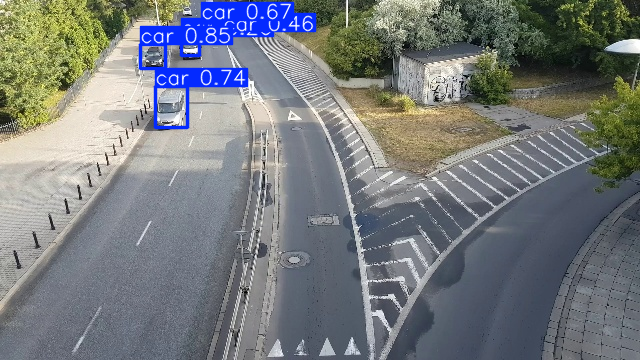

In [13]:
from IPython.display import display
from PIL import Image as PILImage

if len(preds) == 0:
    raise ValueError("No hay predicciones para mostrar.")

# Cambia este índice si quieres ver otra imagen del conjunto de prueba
idx = min(49, len(preds) - 1)

# Ultralytics devuelve una imagen anotada como arreglo BGR; se convierte a RGB para mostrar en notebook.
imagen_anotada_bgr = preds[idx].plot()
imagen_anotada_rgb = imagen_anotada_bgr[:, :, ::-1]

display(PILImage.fromarray(imagen_anotada_rgb))
